In [0]:
%load_ext autoreload
%autoreload 2

# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


In [0]:
%pip install mlflow==3.14.0 langgraph==1.2.9 langchain-core==1.4.9 langchain-openai==1.3.5 databricks-langchain==0.20.0 databricks-vectorsearch==0.75 nest-asyncio==1.6.0 python-dotenv==1.2.2 langchain-mcp-adapters==0.3.0 mcp==1.28.1
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [0]:
# TODO(0.1): load config / verify env vars
# from config import ...

from config import get_settings

settings = get_settings()

print("Host:", settings["host"])
print("Model:", settings["model"])
print("Embeddings:", settings["embeddings"])
print("Vector Search Endpoint:", settings["vs_endpoint"])
print("Vector Search Index:", settings["vs_index"])

Host: https://dbc-be287b92-99e7.cloud.databricks.com
Model: databricks-meta-llama-3-3-70b-instruct
Embeddings: databricks-gte-large-en
Vector Search Endpoint: analyst-vs-endpoint
Vector Search Index: cs4603.default.analyst_index


In [0]:
from databricks.connect import DatabricksSession
spark = (
    DatabricksSession.builder
    .remote(host=settings["host"], token=settings["token"])
    .serverless(True)
    .getOrCreate()
)

In [0]:
# TODO(0.3): ingest corpus -> Delta table -> Vector Search index; wait until READY
# from rag.ingest import ingest
# ingest(spark, volume_path='/Volumes/main/default/pa4/annual_report.pdf')
from rag.ingest import build_chunks_table

build_chunks_table(spark, "/Volumes/main/default/pa4/annual_report.pdf", "main.default.analyst_chunks")


In [0]:
from databricks.vector_search.client import VectorSearchClient

client = VectorSearchClient()  
client.create_endpoint(
    name="analyst-vs-endpoint",
    endpoint_type="STANDARD",
)

/var/folders/rq/25s8zk192r1d675t8r7_tw840000gn/T/ipykernel_55093/1623049452.py:1: DeprecationWarning: databricks-vectorsearch is deprecated and has been renamed to databricks-ai-search. Imports under 'databricks.vector_search.*' will continue to work as a thin re-export of 'databricks.ai_search.*', but new code should switch to 'pip install databricks-ai-search' and 'from databricks.ai_search.* import ...'.
  from databricks.vector_search.client import VectorSearchClient
/Users/alimalik/cs4603-pa4/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'name': 'analyst-vs-endpoint',
 'creator': 'alifayyaz0613@gmail.com',
 'creation_timestamp': 1784334507796,
 'last_updated_timestamp': 1784334507796,
 'endpoint_type': 'STANDARD',
 'last_updated_user': 'alifayyaz0613@gmail.com',
 'id': 'f0c4e000-5989-46b0-9b01-ed22e31ce63c',
 'endpoint_status': {'state': 'ONLINE'},
 'num_indexes': 0}

In [0]:
client.create_delta_sync_index(
    endpoint_name="analyst-vs-endpoint",
    index_name="main.default.analyst_index",
    source_table_name="main.default.analyst_chunks",
    pipeline_type="TRIGGERED",
    primary_key="chunk_id",
    embedding_source_column="chunk_to_retrieve",
    embedding_model_endpoint_name="databricks-gte-large-en",
)

In [0]:
idx = client.get_index(
    endpoint_name="analyst-vs-endpoint",
    index_name="main.default.analyst_index",
)

In [0]:
idx.describe()

{'name': 'main.default.analyst_index',
 'endpoint_name': 'analyst-vs-endpoint',
 'primary_key': 'chunk_id',
 'index_type': 'DELTA_SYNC',
 'delta_sync_index_spec': {'source_table': 'main.default.analyst_chunks',
  'embedding_source_columns': [{'name': 'chunk_to_retrieve',
    'embedding_model_endpoint_name': 'databricks-gte-large-en'}],
  'pipeline_type': 'TRIGGERED',
  'pipeline_id': '3be7a3d9-9094-4f47-84c7-5d717a34b27d'},
 'status': {'detailed_state': 'ONLINE_NO_PENDING_UPDATE',
  'message': 'Index creation succeeded. Check latest status: https://dbc-be287b92-99e7.cloud.databricks.com/explore/data/main/default/analyst_index',
  'indexed_row_count': 7,
  'triggered_update_status': {'last_processed_commit_version': 1,
   'last_processed_commit_timestamp': '2026-07-18T00:18:07Z'},
  'ready': True,
  'index_url': 'dbc-be287b92-99e7.cloud.databricks.com/api/2.0/vector-search/indexes/main.default.analyst_index'},
 'creator': 'alifayyaz0613@gmail.com',
 'endpoint_type': 'STANDARD',
 'id': '

In [0]:
import time

while True:
    status = idx.describe()["status"]
    print(status["detailed_state"], "| ready:", status["ready"])
    if status["ready"] or "FAILED" in status["detailed_state"]:
        break
    time.sleep(20)

PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_ENDPOINT | ready: False
PROVISIONING_INDEX | ready: False
PROVISIONING_INDEX | ready: False
PROVISIONING_INDEX | ready: False
PROVISIONING_PIPELINE_RESOURCES | ready: False
PROVISIONING_INITIAL_SNAPSHOT | ready: False
ONLINE_NO_PENDING_UPDATE | re

In [0]:
from pprint import pp
results = idx.similarity_search(
    query_text="net revenue fiscal year 2023",
    columns=["chunk_id", "chunk_to_retrieve", "source", "page"],
    num_results=3,
)
pp(results)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
{'manifest': {'column_count': 5,
              'columns': [{'name': 'chunk_id'},
                          {'name': 'chunk_to_retrieve'},
                          {'name': 'source'},
                          {'name': 'page'},
                          {'name': 'score'}]},
 'result': {'row_count': 3,
            'data_array': [['c2a5a2aaf5884c51983d01622ed4feea_1',
                            '\n'
                            'All figures in this report are fictional and '
                            'provided solely for CS4603 coursework.\n'
                            '\n'
                            'To our shareholders, customers, and employees: '
                            'Meridian Motor Corporation delivered record '
                            'results in the fiscal year

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [0]:
# TODO(1.7): build the compiled graph
import nest_asyncio
nest_asyncio.apply()

import asyncio
from agent.graph import build_graph, load_mcp_tools

tools = asyncio.run(load_mcp_tools())
graph = build_graph(tools=tools)

/Users/alimalik/cs4603-pa4/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


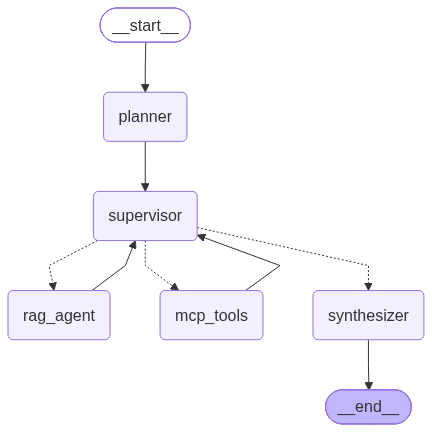

In [0]:
# TODO(1.7): visualize the compiled graph
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



### Test the graph


In [0]:
# Retrieval-only query
graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the net income in 2023?', additional_kwargs={}, response_metadata={}, id='a14e068a-ec61-4df4-a4a4-9ecfa5eb821c'),
  AIMessage(content='According to the information provided in Step 1, the net income for 2023, as stated in the annual report, is ¥1,107 billion. This information can be found in two locations within the document: the "Consolidated Statement of Operations" table on page 1.0 and the "Financial Highlights — Five-Year Summary" table. (Fact produced in Step 1)', additional_kwargs={}, response_metadata={}, id='79931799-199b-42a7-b27f-34967e333530', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Look up net income for 2023 in the annual report'],
 'current_step_index': 1,
 'step_results': ['The net income for 2023, as stated in the annual report, is ¥1,107 billion. This can be found in the table on page 1.0 of the document, under the section "Consolidated Statement of Operations" and also in the "Financial Highlights — Five-Year Su

In [0]:
# Computation-only query
graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})



{'messages': [HumanMessage(content='What is 15% of 2.4 billion?', additional_kwargs={}, response_metadata={}, id='a417640b-9a5a-42c7-bdcd-e7c713600689'),
  AIMessage(content='To calculate 15% of 2.4 billion, we performed the following step:\n\n* Step 1: Calculated 15% of 2.4 billion, which resulted in 0.15 * 2.4e9 = 3.6e+08 (Step 1).\n\nTherefore, 15% of 2.4 billion is 360 million.', additional_kwargs={}, response_metadata={}, id='2bd54366-0133-4221-bd13-203257dbe5ed', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Calculate 15% of 2.4 billion'],
 'current_step_index': 1,
 'step_results': ["Step: Calculate 15% of 2.4 billion\nResult: [{'type': 'text', 'text': '0.15 * 2.4e9 = 3.6e+08', 'id': 'lc_f5db1b40-e729-412a-ad5c-3384e9ea0de5'}]"],
 'next_agent': 'synthesizer',
 'final_answer': 'To calculate 15% of 2.4 billion, we performed the following step:\n\n* Step 1: Calculated 15% of 2.4 billion, which resulted in 0.15 * 2.4e9 = 3.6e+08 (Step 1).\n\nTherefore, 15% of 2.4 billion is 360 

In [0]:
# Combined query — show the full step-by-step execution trace
graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the revenue in 2023, and what would a 10% increase look like?', additional_kwargs={}, response_metadata={}, id='5fb6bfc4-fb65-4d78-afa3-5997a3560f29'),
  AIMessage(content='Based on the provided steps, the following facts have been established:\n\n* The revenue for 2023 is ¥16,910 billion (or ¥16.91 trillion), as stated in Step 1, which cites the annual report\'s "Financial Highlights — Five-Year Summary" section on page 1.0.\n* A 10% increase from the 2023 revenue would result in a new revenue of ¥18.601 trillion, as calculated in Step 2.\n\nTherefore, the final answer is: ¥18.601 trillion, which represents a 10% increase from the 2023 revenue of ¥16.91 trillion.', additional_kwargs={}, response_metadata={}, id='6dbeddd7-f18c-4058-a114-f63bd21cf942', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Look up the revenue for 2023 in the annual report',
  'Calculate a 10% increase from the 2023 revenue found in step 1'],
 'current_step_index'

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [0]:
!python -m pytest tests/test_smoke.py -q


..                                                                       [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [0]:
from databricks_langchain import DatabricksVectorSearch
help(DatabricksVectorSearch)

Help on class DatabricksVectorSearch in module databricks_langchain.vectorstores:

class DatabricksVectorSearch(langchain_core.vectorstores.base.VectorStore)
 |  DatabricksVectorSearch(
 |      index_name: 'str',
 |      endpoint: 'Optional[str]' = None,
 |      embedding: 'Optional[Embeddings]' = None,
 |      text_column: 'Optional[str]' = None,
 |      doc_uri: 'Optional[str]' = None,
 |      primary_key: 'Optional[str]' = None,
 |      columns: 'Optional[List[str]]' = None,
 |      workspace_client: 'Optional[WorkspaceClient]' = None,
 |      client_args: 'Optional[Dict[str, Any]]' = None,
 |      include_score: 'bool' = False,
 |      reranker: 'Optional[DatabricksReranker]' = None
 |  )
 |
 |  Databricks vector store integration.
 |
 |  Args:
 |
 |      index_name: The name of the index to use. Format: "catalog.schema.index".
 |
 |      endpoint: **Deprecated**. This parameter is ignored.
 |          The endpoint name is automatically inferred from the index name.
 |
 |          

In [0]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"



Sun Jul 19 22:38:06 2026 Connection to spark using Py4J from PID  376
Sun Jul 19 22:38:06 2026 Initialized gateway on port 42373
/databricks/python_shell/lib/third_party/python/vendor/protobuf/google/protobuf/internal/api_implementation.py:120: UserWarning: Selected implementation upb is not available. Falling back to the python implementation.
  warnings.warn('Selected implementation upb is not available. '
Sun Jul 19 22:38:06 2026 Connected to spark using Py4J in SparkMode.REMOTE_CONNECT mode.


In [0]:
# TODO(2.2): log + register the model version in Unity Catalog
from deployment.deploy import log_and_register
uc_name, version = log_and_register()


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/19 22:39:53 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o11.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jC

[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


/local_disk0/.ephemeral_nfs/envs/pythonEnv-a513e48e-0757-406f-96cc-1d646c46e4a5/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/19 22:40:14 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-ddfd029989804035a0b2f0d2a5c299e1
2026/07/19 22:40:14 INFO mlflow.tracking.fluen

[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/19 22:40:29 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
2026/07/19 22:40:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o27.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.data

Uploading artifacts:   0%|          | 0/28 [00:00<?, ?it/s]

Registered model: main.default.document_analyst, version 19


🔗 Created version '19' of model 'main.default.document_analyst': https://dbc-be287b92-99e7.cloud.databricks.com/explore/data/models/main/default/document_analyst/version/19?o=7474650104002234


In [0]:
# TODO(2.3): create/update the serving endpoint; wait for READY; print the URL
from deployment.deploy import create_or_update_endpoint
url = create_or_update_endpoint(uc_name=uc_name, version=version)
print(url)

1. Creating WorkspaceClient...
2. WorkspaceClient created
3. Endpoint name: alifayyaz-document-analyst
4. Listing endpoints...
5. Found 19 endpoints
6. Existing endpoint: False
ready=EndpointStateReady.READY, config_update=EndpointStateConfigUpdate.NOT_UPDATING
Endpoint URL: https://dbc-be287b92-99e7.cloud.databricks.com/serving-endpoints/alifayyaz-document-analyst/invocations
https://dbc-be287b92-99e7.cloud.databricks.com/serving-endpoints/alifayyaz-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [0]:
# curl the endpoint and show the raw response
import os

endpoint_name = os.environ["SERVING_ENDPOINT_NAME"]
host = os.environ["DATABRICKS_HOST"]
token = os.environ["DATABRICKS_TOKEN"]

!curl -s -X POST {host}/serving-endpoints/{endpoint_name}/invocations \
  -H "Authorization: Bearer {token}" \
  -H "Content-Type: application/json" \
  -d '{{"messages":[{{"role":"user","content":"What was the net income in 2023?"}}]}}'


[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "d0a80e76-1d17-4784-8049-2be2b0f2615d"}, {"content": "The net income attributable to owners of the parent for the fiscal year 2023 is \u00a51,107 billion, as stated in the annual report (Step 1). This information is consistently reported across multiple sections of the annual report, including the table on pages 1.0 and 3.0, as well as the forecast section on page 12.0, where it is referred to as \"Net income (\u00a5B)\" and listed as 1,107 (Step 1). Therefore, the net income for the fiscal year 2023 is confirmed to be \u00a51,107 billion.", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "e3f93c11-4b5c-4295-b7f2-d283c21cb886", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Look up net income for 2023 in the annual report"], "current_step_index": 1, "step_results": ["Acc

In [0]:
# Response shape depends on how you logged the model (see README Task 2.4 / GUIDE §7).
#
# Path A — raw LangGraph state (mlflow.langchain.log_model, v1 style):
# import requests
# url = f'{DATABRICKS_HOST}/serving-endpoints/<your-endpoint-name>/invocations'
# r = requests.post(url, headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
#                   json={'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
# print(r.json()[0]['messages'][-1]['content'])
#
# Path B — OpenAI ChatCompletion (mlflow.pyfunc.ChatModel / ChatAgent, v2 style):
# import openai
# client = openai.OpenAI(api_key=DATABRICKS_TOKEN, base_url=f'{DATABRICKS_HOST}/serving-endpoints')
# resp = client.chat.completions.create(model='<your-endpoint-name>',
#     messages=[{'role':'user','content':'What was the net income in 2023?'}])
# print(resp.choices[0].message.content)
import os
import requests

host = os.environ["DATABRICKS_HOST"]
token = os.environ["DATABRICKS_TOKEN"]
url = "https://dbc-be287b92-99e7.cloud.databricks.com/serving-endpoints/alifayyaz-document-analyst/invocations" 

r = requests.post(
    url,
    headers={"Authorization": f"Bearer {token}"},
    json={"messages": [{"role": "user", "content": "What was the net income in 2023?"}]},
)

print("Status code:", r.status_code)
data = r.json()
print("Raw response:", data)
print("\nParsed answer:", data[0]["messages"][-1]["content"])


Status code: 200
Raw response: [{'messages': [{'content': 'What was the net income in 2023?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '98382d1d-86ab-47f8-8449-bd4292c7d43b'}, {'content': 'According to the information provided in Step 1, the net income for 2023, specifically for "Net income (owners)", is ¥1,107 billion, as stated in the annual_report.pdf on pages 1.0 and 3.0. \n\nTherefore, the final answer is: The net income for 2023 is ¥1,107 billion. (Fact produced in Step 1)', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'name': None, 'id': 'efae9218-0fbe-4f87-b740-673b0818c627', 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}], 'plan': ['Look up net income for 2023 in the annual report'], 'current_step_index': 1, 'step_results': ['The net income for 2023, specifically "Net income (owners)", is ¥1,107 billion. \n\nSource: annual_report.pdf, page 1.0 and page 3.0.'], 'next_agent': 'synthesizer', 'fi

## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [0]:
import importlib
import client.sdk

importlib.reload(client.sdk)

<module 'client.sdk' from '/Workspace/Users/alifayyaz0613@gmail.com/cs4603-pa4/client/sdk.py'>

In [0]:
from databricks.sdk import WorkspaceClient

w = WorkspaceClient()
ep = w.serving_endpoints.get("alifayyaz-document-analyst")

print(ep.state)
print(ep.state.ready)
print(type(ep.state.ready))

EndpointState(config_update=<EndpointStateConfigUpdate.NOT_UPDATING: 'NOT_UPDATING'>, ready=<EndpointStateReady.READY: 'READY'>)
EndpointStateReady.READY
<enum 'EndpointStateReady'>


In [0]:
from client.sdk import DocumentAnalystClient
c = DocumentAnalystClient(
    endpoint_name="alifayyaz-document-analyst",
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
)
assert c.health_check() is True
print(c.ask('What was the net income in 2023?'))



Based on the information provided in Step 1, the net income attributable to owners of the parent for the fiscal year ended March 31, 2023 (FY2023) is ¥1,107 billion. This fact is supported by multiple sources within the annual report, including a summary table on page 1.0 and a detailed statement on page 3.0, as cited in the document metadata 'c2a5a2aaf5884c51983d01622ed4feea_1' from the source 'annual_report.pdf'. 

Therefore, the final answer is: The net income attributable to owners of the parent for FY2023 is ¥1,107 billion, as reported in the annual report (Source: annual_report.pdf, pages 1.0 and 3.0, Step 1).


In [0]:
# ask_streaming demo
for chunk in c.ask_streaming('Summarize FY2023 revenue.'): 
    print(chunk, end='')



The net revenue for FY2023 is ¥16,910 billion, as stated in the annual report (source: 'annual_report.pdf', page 3.0), which was identified in **Step 1**. This information is based on the provided document metadata, specifically chunk ID 'c2a5a2aaf5884c51983d01622ed4feea_2'.

In [0]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior
from client.sdk import AnalystClientError

timeout_client = DocumentAnalystClient(
    endpoint_name="alifayyaz-document-analyst",
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
    timeout=0.001,
)

try:
    timeout_client.ask("What was the net income in 2023?")
except TimeoutError as e:
    print("Caught expected TimeoutError:", e)


Caught expected TimeoutError: Request timed out after 0.0s (limit: 0.001s)


In [0]:
# Simulating endpoint unavailable 
bad_client = DocumentAnalystClient(
    endpoint_name="this-endpoint-does-not-exist",
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
    max_retries=2,
)

try:
    bad_client.ask("test")
except AnalystClientError as e:
    print("Caught expected AnalystClientError:")
    print("  status_code:", e.status_code)
    print("  message:", str(e))

Caught expected AnalystClientError:
  status_code: 404
  message: Request failed: 404 {"error_code":"ENDPOINT_NOT_FOUND","message":"The given endpoint does not exist, please retry after checking the specified model and version deployment exists."}
